# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist

In [2]:
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# Load Dataset

In [3]:
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

In [4]:
print(f"Raw Training data shape: {X_train_raw.shape}")
print(f"Raw Test data shape: {X_test_raw.shape}")

Raw Training data shape: (60000, 28, 28)
Raw Test data shape: (10000, 28, 28)


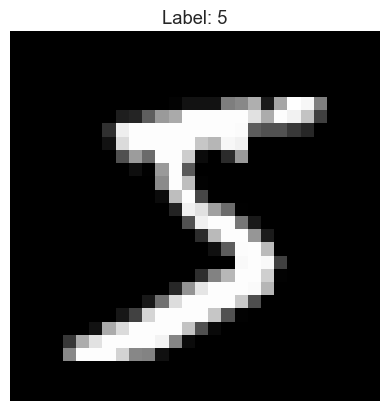

In [5]:
plt.imshow(X_train_raw[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

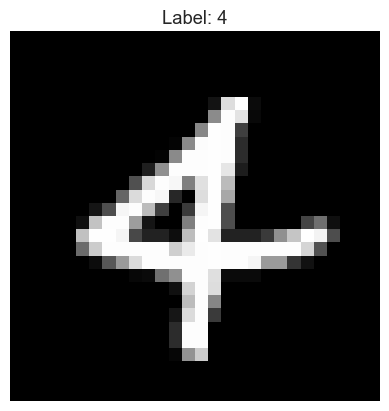

In [6]:
plt.imshow(X_train_raw[150], cmap='gray')
plt.title(f"Label: {y_train[150]}")
plt.axis('off')
plt.show()

### Subsample the data for faster prototyping

In [7]:
train_subset_size = 10000
test_subset_size = 2000

X_train_sub = X_train_raw[:train_subset_size]
y_train_sub = y_train[:train_subset_size]

X_test_sub = X_test_raw[:test_subset_size]
y_test_sub = y_test[:test_subset_size]

### Flatten the 2D images (28x28) into 1D arrays (784)

In [8]:
X_train_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1)

### Scale the pixel values to be between 0.0 and 1.0

In [9]:
X_train_scaled = X_train_flat.astype('float32') / 255.0
X_test_scaled = X_test_flat.astype('float32') / 255.0

In [10]:
print(f"Final Training Data Shape: {X_train_scaled.shape}")
print(f"Final Test Data Shape: {X_test_scaled.shape}")
print(f"Min pixel value: {X_train_scaled.min()}, Max pixel value: {X_train_scaled.max()}")

Final Training Data Shape: (10000, 784)
Final Test Data Shape: (2000, 784)
Min pixel value: 0.0, Max pixel value: 1.0


# Linear SVM Baseline

In [11]:
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
linear_svm = SVC(kernel='linear', random_state=42)

In [13]:
start_time = time.time()

linear_svm.fit(X_train_scaled, y_train_sub)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds.")

Training completed in 29.53 seconds.


In [14]:
inference_start = time.time()
y_pred_linear = linear_svm.predict(X_test_scaled)
inference_time = time.time() - inference_start
print(f"Inference completed in {inference_time:.2f} seconds.")

Inference completed in 9.46 seconds.


In [15]:
baseline_accuracy = accuracy_score(y_test_sub, y_pred_linear)

print(f"Baseline Linear SVM Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Linear SVM Accuracy: 89.75%


In [16]:
print(classification_report(y_test_sub, y_pred_linear))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       175
           1       0.96      0.99      0.98       234
           2       0.89      0.89      0.89       219
           3       0.84      0.88      0.86       207
           4       0.90      0.94      0.92       217
           5       0.89      0.84      0.87       179
           6       0.90      0.93      0.91       178
           7       0.89      0.86      0.88       205
           8       0.89      0.83      0.86       192
           9       0.89      0.84      0.86       194

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



In [17]:
cm = confusion_matrix(y_test_sub, y_pred_linear)

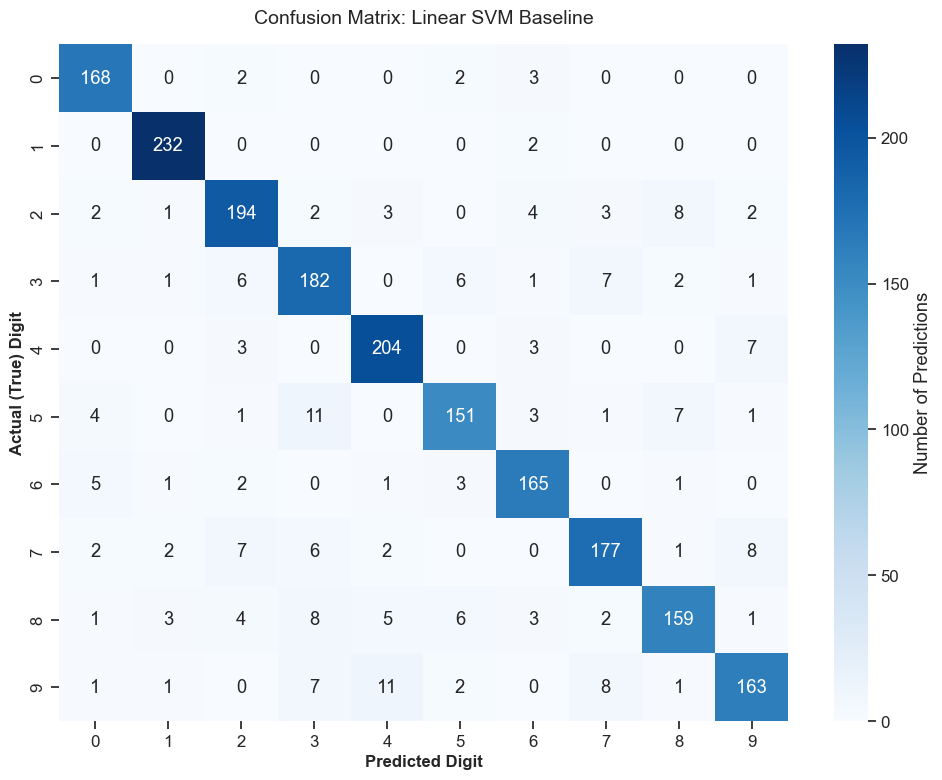

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('Actual (True) Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Linear SVM Baseline', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Radial Basis Function SVM

In [19]:
rbf_svm = SVC(kernel='rbf', random_state=42)

In [20]:
start_time = time.time()

rbf_svm.fit(X_train_scaled, y_train_sub)

rbf_training_time = time.time() - start_time
print(f"RBF Training completed in {rbf_training_time:.2f} seconds.")

RBF Training completed in 51.72 seconds.


In [21]:
inference_start = time.time()
y_pred_rbf = rbf_svm.predict(X_test_scaled)
rbf_inference_time = time.time() - inference_start
print(f"RBF Inference completed in {rbf_inference_time:.2f} seconds.")

RBF Inference completed in 17.95 seconds.


In [22]:
rbf_accuracy = accuracy_score(y_test_sub, y_pred_rbf)
print(f"Advanced RBF SVM Accuracy: {rbf_accuracy * 100:.2f}%")

Advanced RBF SVM Accuracy: 94.45%


In [23]:
print(classification_report(y_test_sub, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       175
           1       0.97      0.99      0.98       234
           2       0.95      0.96      0.95       219
           3       0.92      0.92      0.92       207
           4       0.95      0.95      0.95       217
           5       0.95      0.93      0.94       179
           6       0.94      0.96      0.95       178
           7       0.93      0.91      0.92       205
           8       0.95      0.92      0.93       192
           9       0.93      0.91      0.92       194

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [24]:
cm = confusion_matrix(y_test_sub, y_pred_linear)

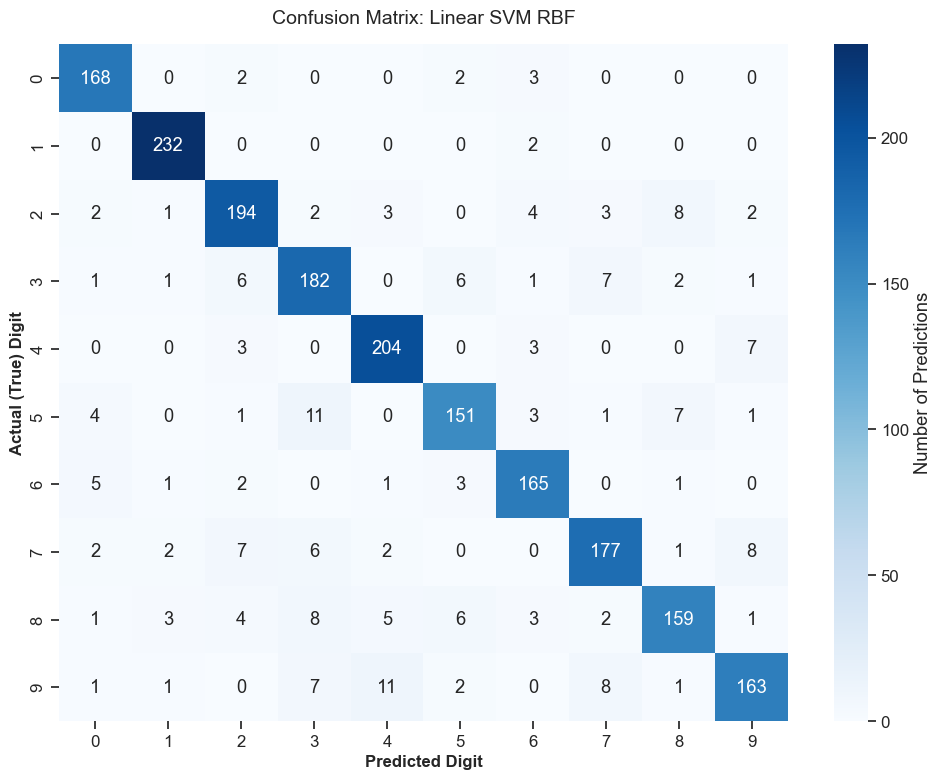

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('Actual (True) Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Linear SVM RBF', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Best SVM (PCA + Grid Search)

In [26]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import time

In [27]:
pca = PCA(n_components=0.95, random_state=42)

In [28]:
pipeline = Pipeline([
    ('pca', pca),
    ('svm', SVC(kernel='rbf', random_state=42))
])

In [29]:
param_grid = {
    'svm__C': [1, 10, 50],
    'svm__gamma': ['scale', 0.01, 0.05]
}

In [30]:
grid_start = time.time()

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train_sub)

grid_time = time.time() - grid_start
print(f"Grid Search completed in {grid_time:.2f} seconds.")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Grid Search completed in 174.33 seconds.


In [31]:
print(f"Best Parameters Found: {grid_search.best_params_}")

Best Parameters Found: {'svm__C': 10, 'svm__gamma': 'scale'}


In [32]:
best_svm = grid_search.best_estimator_

In [33]:
test_start = time.time()
best_svm_preds = best_svm.predict(X_test_scaled)
test_time = time.time() - test_start

In [34]:
print(f"Optimized Inference Time: {test_time:.2f} seconds.")

Optimized Inference Time: 3.26 seconds.


In [35]:
print(f"Optimized SVM Accuracy: {accuracy_score(y_test_sub, best_svm_preds) * 100:.2f}%")

Optimized SVM Accuracy: 95.65%


In [36]:
print(classification_report(y_test_sub, best_svm_preds))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       175
           1       0.98      0.99      0.99       234
           2       0.95      0.96      0.96       219
           3       0.95      0.96      0.95       207
           4       0.96      0.96      0.96       217
           5       0.98      0.95      0.96       179
           6       0.93      0.97      0.95       178
           7       0.95      0.92      0.94       205
           8       0.96      0.95      0.96       192
           9       0.93      0.92      0.92       194

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



In [37]:
cm = confusion_matrix(y_test_sub, y_pred_linear)

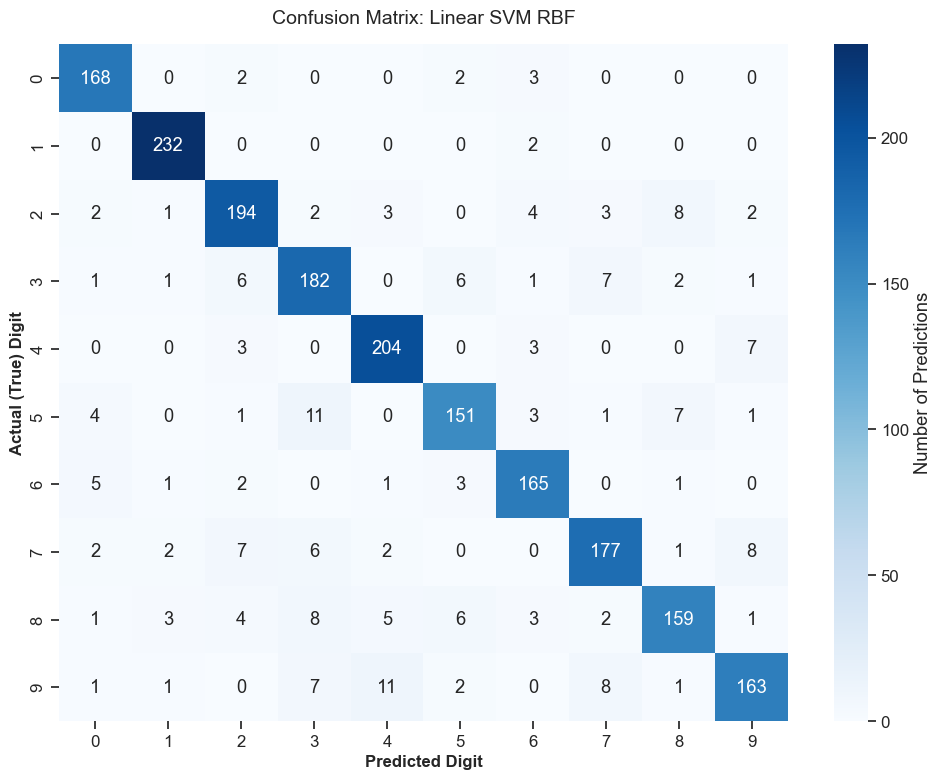

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('Actual (True) Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Linear SVM RBF', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Save the Model

In [39]:
import joblib
import os

In [40]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

In [41]:
model_path = os.path.join(model_dir, 'optimized_svm_pipeline.joblib')

In [42]:
joblib.dump(grid_search.best_estimator_, model_path)

['../models\\optimized_svm_pipeline.joblib']

In [43]:
print(f"Model successfully saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / (1024 * 1024):.2f} MB")

Model successfully saved to: ../models\optimized_svm_pipeline.joblib
File size: 5.41 MB
